In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

Using device: cpu


100%|██████████| 170M/170M [49:04<00:00, 57.9kB/s]


Training set size: 50000
Testing set size: 10000
Image shape: torch.Size([3, 32, 32])
Number of classes: 10


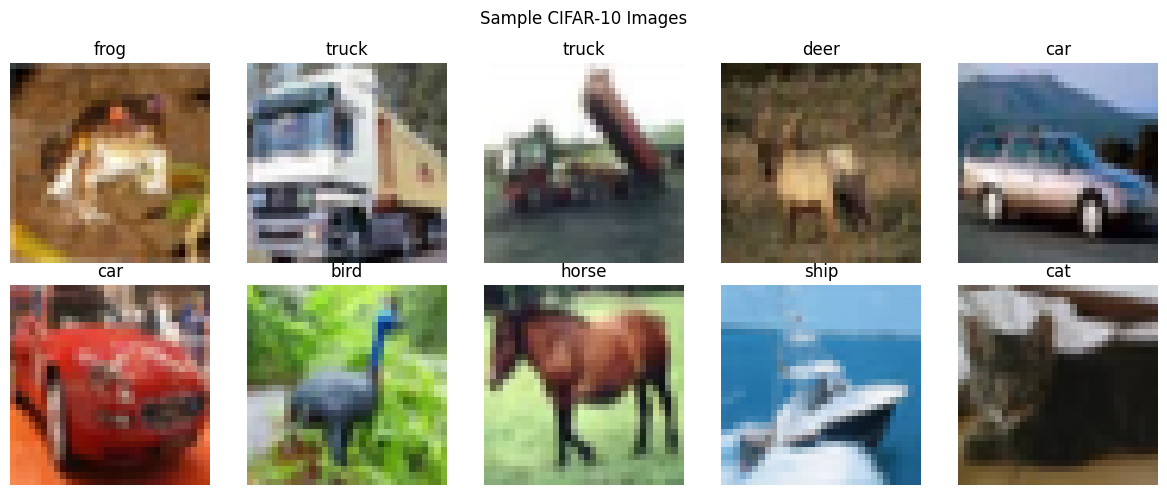

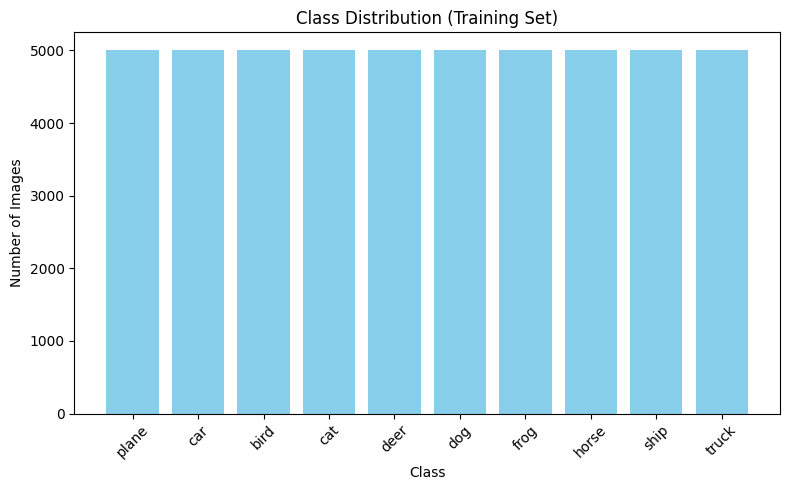

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

print("Training set size:", len(trainset))
print("Testing set size:", len(testset))
print("Image shape:", trainset[0][0].shape)
print("Number of classes:", len(classes))

# Display 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = trainset[i]
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

# Class distribution
train_labels = [label for _, label in trainset]
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar([classes[u] for u in unique], counts, color='skyblue')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Training Set)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [3]:
import matplotlib as mpl

# Global plot styling — Liberation Serif (Times New Roman substitute), size 14 bold
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['savefig.dpi'] = 600

def save_fig(fig, name):
    """Save a figure as both EPS and PDF at 600 DPI."""
    fig.savefig(f"{name}.eps", format='eps', dpi=600, bbox_inches='tight')
    fig.savefig(f"{name}.pdf", format='pdf', dpi=600, bbox_inches='tight')

Training set size: 50000
Testing set size: 10000
Image shape: torch.Size([3, 32, 32])
Number of classes: 10


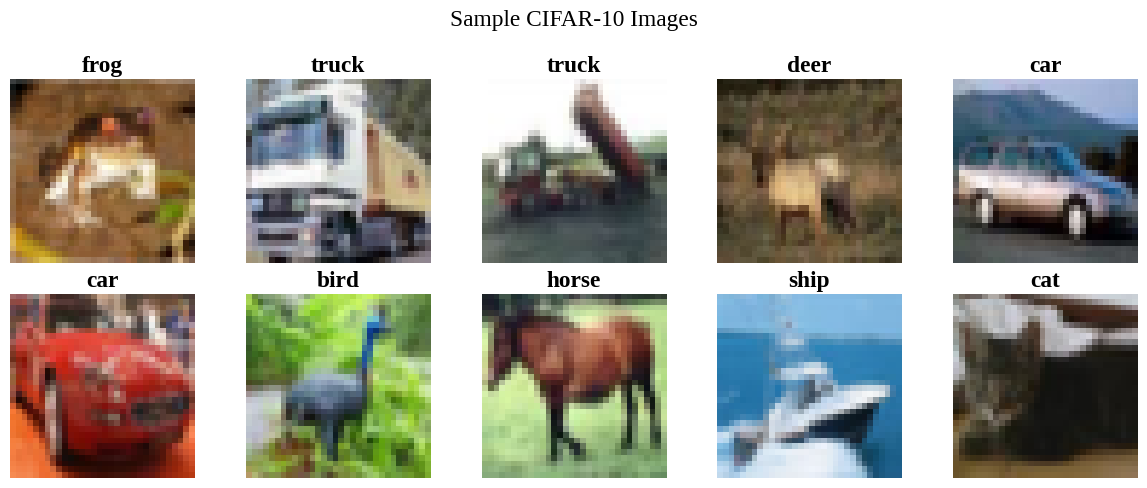

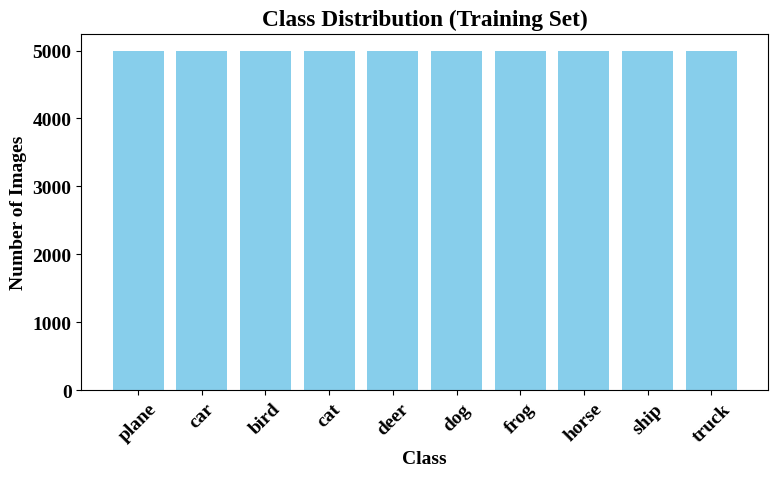

In [4]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

print("Training set size:", len(trainset))
print("Testing set size:", len(testset))
print("Image shape:", trainset[0][0].shape)
print("Number of classes:", len(classes))

# Display 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = trainset[i]
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
save_fig(fig, "sample_images")
plt.show()

# Class distribution
train_labels = [label for _, label in trainset]
unique, counts = np.unique(train_labels, return_counts=True)

fig = plt.figure(figsize=(8, 5))
plt.bar([classes[u] for u in unique], counts, color='skyblue')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Training Set)")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig(fig, "class_distribution")
plt.show()

Kernel    Output Size    Formula Result
3x3       (30, 30)       30x30
5x5       (28, 28)       28x28
7x7       (26, 26)       26x26


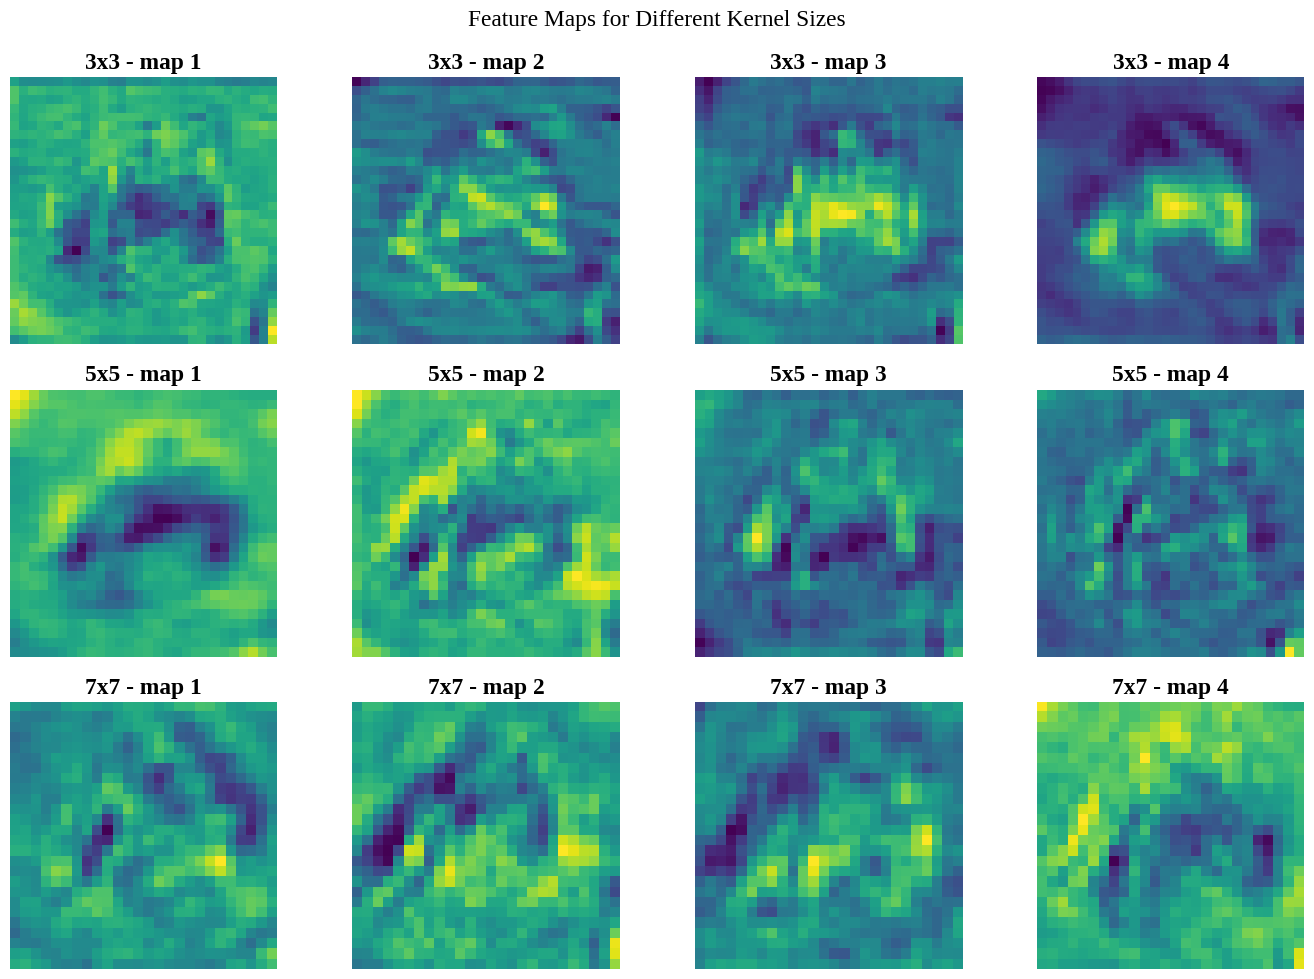

In [5]:
def get_output_size(N, F_size, P, S):
    return (N - F_size + 2*P) // S + 1

sample_img, _ = trainset[0]
sample_img = sample_img.unsqueeze(0).to(device)  # (1, 3, 32, 32)

kernel_sizes = [3, 5, 7]
print(f"{'Kernel':<10}{'Output Size':<15}{'Formula Result'}")
for k in kernel_sizes:
    conv = nn.Conv2d(3, 8, kernel_size=k, stride=1, padding=0).to(device)
    out = conv(sample_img)
    formula_size = get_output_size(32, k, 0, 1)
    print(f"{k}x{k:<8}{str(tuple(out.shape[2:])):<15}{formula_size}x{formula_size}")

# Visualize feature maps for each kernel size
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, k in enumerate(kernel_sizes):
    conv = nn.Conv2d(3, 8, kernel_size=k, stride=1, padding=0).to(device)
    out = conv(sample_img).detach().cpu().squeeze(0)
    for col in range(4):
        axes[row, col].imshow(out[col], cmap='viridis')
        axes[row, col].set_title(f"{k}x{k} - map {col+1}")
        axes[row, col].axis('off')
plt.suptitle("Feature Maps for Different Kernel Sizes")
plt.tight_layout()
save_fig(fig, "kernel_comparison")
plt.show()

In [6]:
print("Stride and Padding Effects (Input=32x32, Kernel=3x3)\n")
configs = [
    {"stride": 1, "padding": 0, "name": "Stride=1, Padding=Valid(0)"},
    {"stride": 2, "padding": 0, "name": "Stride=2, Padding=Valid(0)"},
    {"stride": 1, "padding": 1, "name": "Stride=1, Padding=Same(1)"},
    {"stride": 2, "padding": 1, "name": "Stride=2, Padding=Same-ish(1)"},
]

print(f"{'Configuration':<35}{'Formula Output':<18}{'Actual Output'}")
for cfg in configs:
    conv = nn.Conv2d(3, 8, kernel_size=3, stride=cfg["stride"],
                      padding=cfg["padding"]).to(device)
    out = conv(sample_img)
    formula = get_output_size(32, 3, cfg["padding"], cfg["stride"])
    print(f"{cfg['name']:<35}{f'{formula}x{formula}':<18}{tuple(out.shape[2:])}")

Stride and Padding Effects (Input=32x32, Kernel=3x3)

Configuration                      Formula Output    Actual Output
Stride=1, Padding=Valid(0)         30x30             (30, 30)
Stride=2, Padding=Valid(0)         15x15             (15, 15)
Stride=1, Padding=Same(1)          32x32             (32, 32)
Stride=2, Padding=Same-ish(1)      16x16             (16, 16)


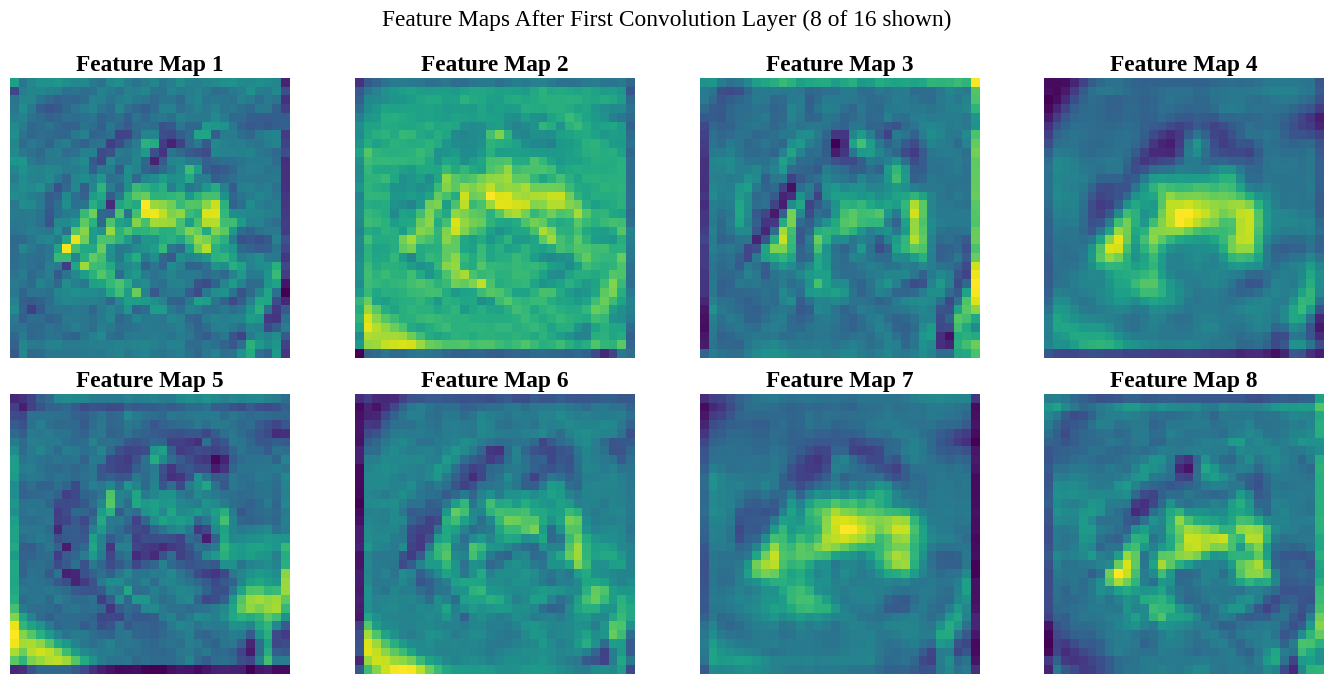

In [7]:
class FeatureMapNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

fm_net = FeatureMapNet().to(device)
feature_maps = fm_net(sample_img).detach().cpu().squeeze(0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap='viridis')
    ax.set_title(f"Feature Map {i+1}")
    ax.axis('off')
plt.suptitle("Feature Maps After First Convolution Layer (8 of 16 shown)")
plt.tight_layout()
save_fig(fig, "feature_maps_conv1")
plt.show()

Original feature map size: torch.Size([32, 32])
After Max Pooling: torch.Size([16, 16])
After Avg Pooling: torch.Size([16, 16])


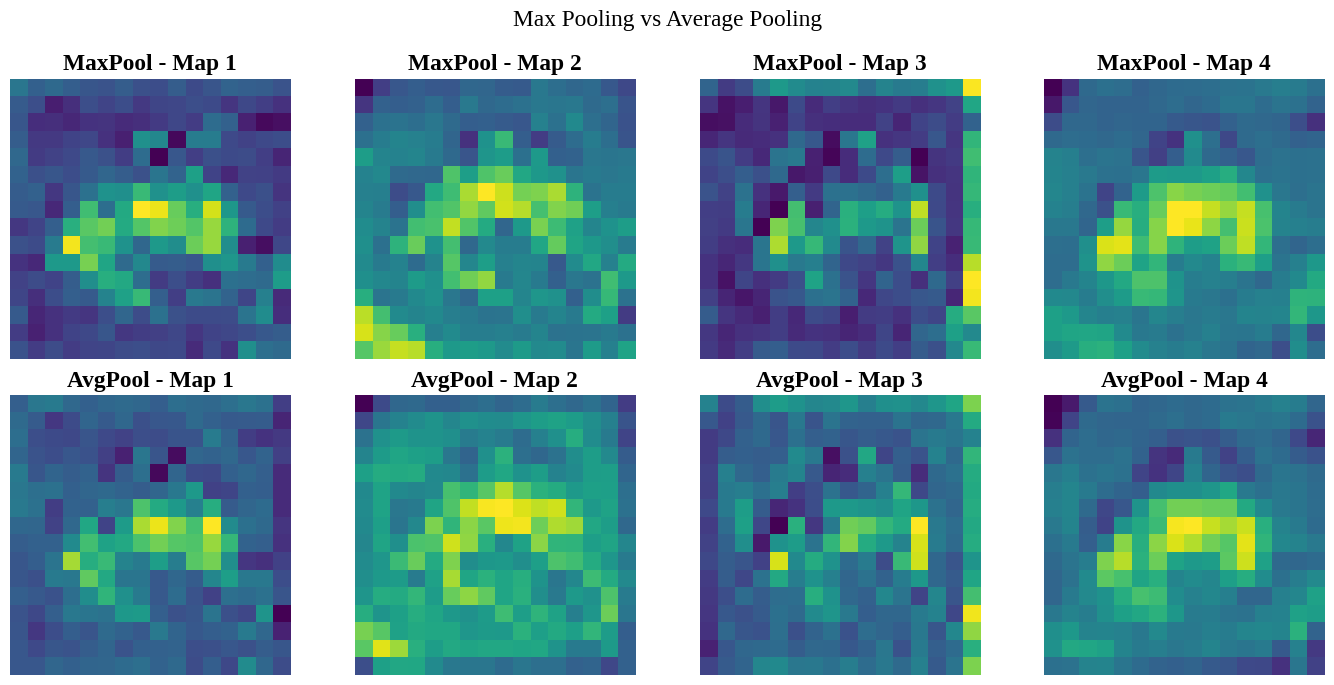

In [8]:
maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
avgpool = nn.AvgPool2d(kernel_size=2, stride=2)

max_out = maxpool(feature_maps.unsqueeze(0)).squeeze(0)
avg_out = avgpool(feature_maps.unsqueeze(0)).squeeze(0)

print("Original feature map size:", feature_maps.shape[1:])
print("After Max Pooling:", max_out.shape[1:])
print("After Avg Pooling:", avg_out.shape[1:])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(max_out[i], cmap='viridis')
    axes[0, i].set_title(f"MaxPool - Map {i+1}")
    axes[0, i].axis('off')
    axes[1, i].imshow(avg_out[i], cmap='viridis')
    axes[1, i].set_title(f"AvgPool - Map {i+1}")
    axes[1, i].axis('off')
plt.suptitle("Max Pooling vs Average Pooling")
plt.tight_layout()
save_fig(fig, "pooling_comparison")
plt.show()

In [9]:
# Prepare data loaders with train/val split
val_size = 5000
train_size = len(trainset) - val_size
train_subset, val_subset = random_split(trainset, [train_size, val_size],
                                         generator=torch.Generator().manual_seed(42))

batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total trainable parameters: 268650
Epoch [1/20] Train Loss: 1.5594, Train Acc: 0.4360 | Val Loss: 1.3479, Val Acc: 0.5080
Epoch [2/20] Train Loss: 1.2392, Train Acc: 0.5576 | Val Loss: 1.3019, Val Acc: 0.5408
Epoch [3/20] Train Loss: 1.0930, Train Acc: 0.6134 | Val Loss: 1.0893, Val Acc: 0.6084
Epoch [4/20] Train Loss: 0.9896, Train Acc: 0.6524 | Val Loss: 1.0372, Val Acc: 0.6330
Epoch [5/20] Train Loss: 0.9135, Train Acc: 0.6801 | Val Loss: 1.0181, Val Acc: 0.6428
Epoch [6/20] Train Loss: 0.8

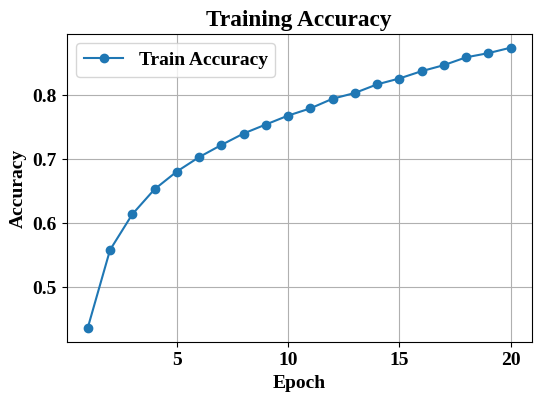

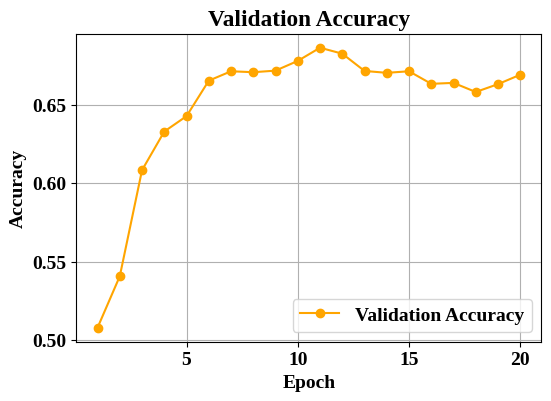

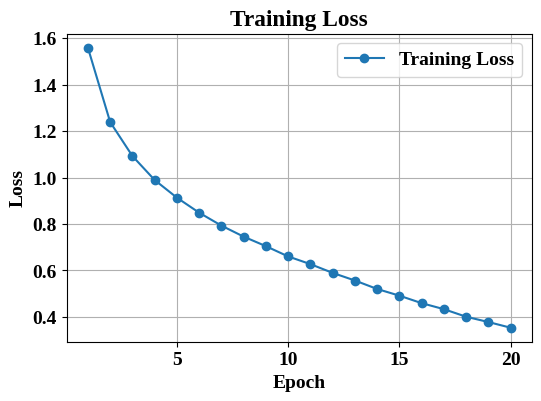

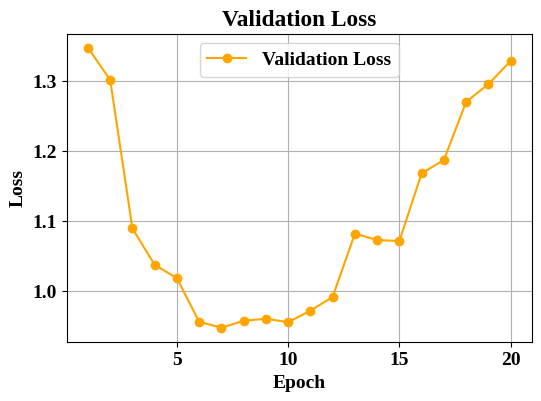

In [10]:
epochs_range = range(1, epochs + 1)

fig = plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy", marker='o')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training Accuracy")
plt.legend(); plt.grid(True)
save_fig(fig, "training_accuracy")
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy",
         marker='o', color='orange')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Validation Accuracy")
plt.legend(); plt.grid(True)
save_fig(fig, "validation_accuracy")
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history["train_loss"], label="Training Loss", marker='o')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training Loss")
plt.legend(); plt.grid(True)
save_fig(fig, "training_loss")
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history["val_loss"], label="Validation Loss",
         marker='o', color='orange')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Validation Loss")
plt.legend(); plt.grid(True)
save_fig(fig, "validation_loss")
plt.show()

Test Accuracy : 0.6673
Precision     : 0.6653
Recall        : 0.6673
F1-score      : 0.6649
Total Parameters: 268650

Classification Report:

              precision    recall  f1-score   support

       plane       0.70      0.71      0.71      1000
         car       0.78      0.78      0.78      1000
        bird       0.60      0.49      0.54      1000
         cat       0.47      0.45      0.46      1000
        deer       0.60      0.61      0.61      1000
         dog       0.59      0.57      0.58      1000
        frog       0.66      0.81      0.73      1000
       horse       0.72      0.71      0.72      1000
        ship       0.78      0.79      0.79      1000
       truck       0.74      0.74      0.74      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.66     10000
weighted avg       0.67      0.67      0.66     10000



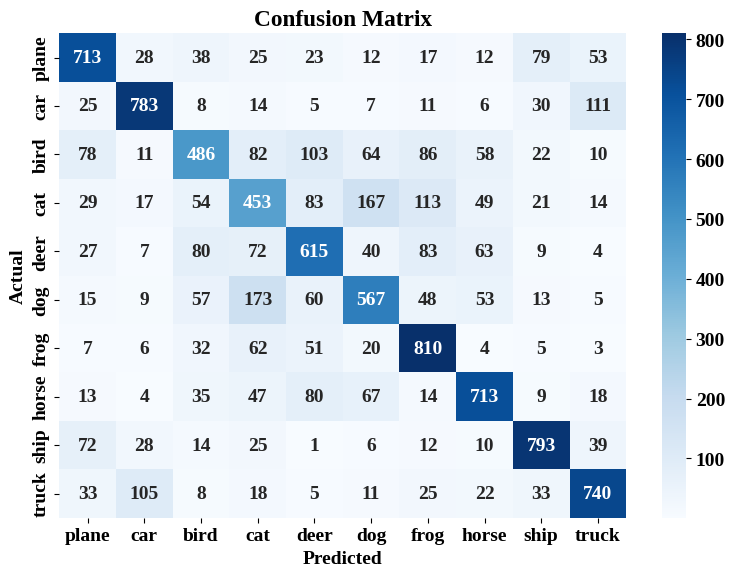

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average='macro')
test_recall = recall_score(all_labels, all_preds, average='macro')
test_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1-score      : {test_f1:.4f}")
print(f"Total Parameters: {total_params}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.tight_layout()
save_fig(fig, "confusion_matrix")
plt.show()

In [12]:
import shutil
from google.colab import files
import os

# Create a folder and move all figure files into it
os.makedirs("figures", exist_ok=True)

figure_names = [
    "sample_images",
    "class_distribution",
    "kernel_comparison",
    "feature_maps_conv1",
    "pooling_comparison",
    "training_accuracy",
    "validation_accuracy",
    "training_loss",
    "validation_loss",
    "confusion_matrix"
]

for name in figure_names:
    for ext in [".eps", ".pdf"]:
        fname = f"{name}{ext}"
        if os.path.exists(fname):
            shutil.move(fname, os.path.join("figures", fname))
        else:
            print(f"Warning: {fname} not found — check it was generated.")

# Zip the figures folder
shutil.make_archive("Experiment3_Figures", 'zip', "figures")

# Download the zip
files.download("Experiment3_Figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>